In [ ]:
!pip install prophet

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from sklearn.metrics import mean_absolute_error, mean_squared_error
from prophet import Prophet
import numpy as np

In [ ]:
df = pd.read_csv('df_top10.csv')

In [ ]:
df

,RegionNombre,Semana,Atenciones_Urg,Temp_Mediana_Semanal,PM25_Mediana_Semanal,Mes,Region_Corta,PM25_Lag1,PM25_Lag2
0,RM,2020-12-29,3483,21.375,13.312500,12,RM,13.312500,13.312500
1,RM,2021-01-05,5338,19.300,13.318452,1,RM,13.312500,13.312500
2,RM,2021-01-12,4956,19.900,12.934783,1,RM,13.318452,13.312500
3,RM,2021-01-19,4563,21.300,17.208333,1,RM,12.934783,13.318452
4,RM,2021-01-26,4289,18.900,11.791667,1,RM,17.208333,12.934783
...,...,...,...,...,...,...,...,...,...
2615,Maule,2025-12-02,9817,21.400,15.708333,12,Maule,14.916667,16.583333
2616,Maule,2025-12-09,8509,18.700,14.020833,12,Maule,15.708333,14.916667
2617,Maule,2025-12-16,7557,20.600,13.166667,12,Maule,14.020833,15.708333
2618,Maule,2025-12-23,7048,21.800,15.541667,12,Maule,13.166667,14.020833


In [ ]:
cols_a_completar = ['Atenciones_Urg', 'Temp_Mediana_Semanal', 'PM25_Mediana_Semanal','PM25_Lag1','PM25_Lag2']

for col in cols_a_completar:
    # Agrupamos por región para que el promedio sea local y no mezcle zonas
    df[col] = df.groupby('RegionNombre')[col].transform(
        lambda x: x.interpolate(method='linear', limit_direction='both')
    )

#
print("Nulos restantes en el Top 10:")
print(df[cols_a_completar].isnull().sum())

Nulos restantes en el Top 10:
Atenciones_Urg          0
Temp_Mediana_Semanal    0
PM25_Mediana_Semanal    0
PM25_Lag1               0
PM25_Lag2               0
dtype: int64


In [ ]:
df_valpo = df[df['RegionNombre'] == 'Valparaíso'].copy()

# Preparamos el formato para Prophet
df_prophet = df_valpo[['Semana', 'Atenciones_Urg', 'PM25_Lag1', 'Temp_Mediana_Semanal']].copy()
df_prophet.columns = ['ds', 'y', 'pm25_lag', 'temp']

# Dividimos entre entrenamiento y prueba
train = df_prophet[df_prophet['ds'] < '2025-01-01']
test = df_prophet[df_prophet['ds'] >= '2025-01-01']

In [ ]:
df_valpo.isnull().sum()

,0
RegionNombre,0
Semana,0
Atenciones_Urg,0
Temp_Mediana_Semanal,0
PM25_Mediana_Semanal,0
Mes,0
Region_Corta,0
PM25_Lag1,0
PM25_Lag2,0


In [ ]:
df_prophet

,ds,y,pm25_lag,temp
1310,2020-12-29,776,12.705611,16.75
1311,2021-01-05,1293,12.705611,16.20
1312,2021-01-12,1333,13.337619,15.70
1313,2021-01-19,1146,15.272000,16.90
1314,2021-01-26,1137,10.045000,18.40
...,...,...,...,...
1567,2025-12-02,7587,16.000000,17.55
1568,2025-12-09,6796,18.958333,17.00
1569,2025-12-16,5996,16.958333,17.30
1570,2025-12-23,5787,19.333333,17.80


In [ ]:
m_prophet = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False,
    stan_backend='CMDSTANPY')

# Añadimos nuestras variables clave como "regresores"
m_prophet.add_regressor('pm25_lag')
m_prophet.add_regressor('temp')

# Entrenamos el modelo
m_prophet.fit(train)

# predecimos
forecast = m_prophet.predict(test)

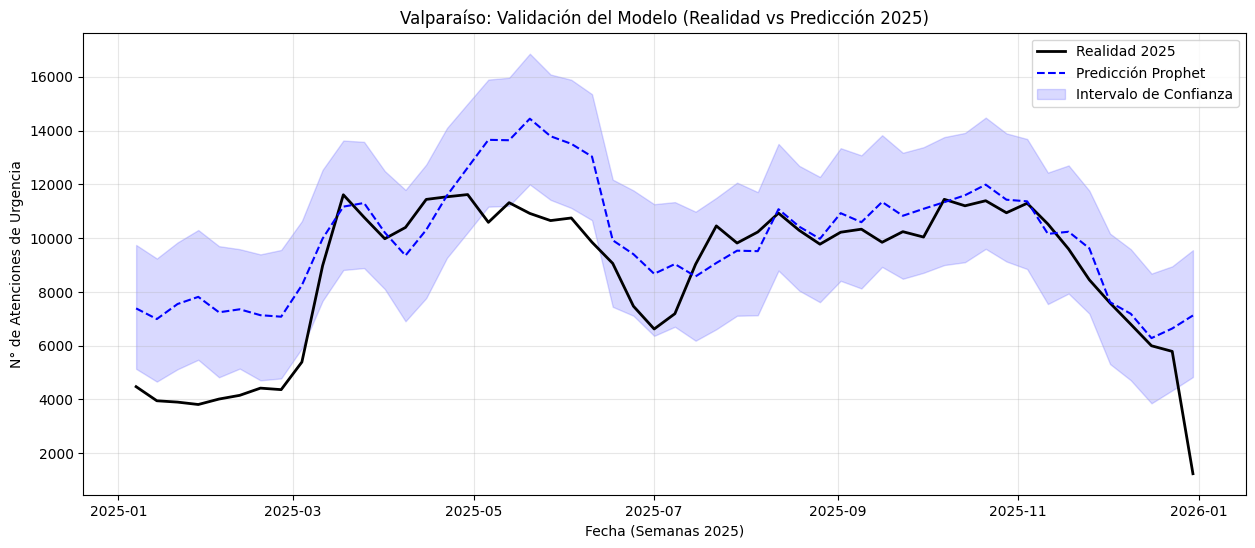

In [ ]:
test_plot = test.copy()
test_plot['ds'] = pd.to_datetime(test_plot['ds']).dt.tz_localize(None)

forecast_plot = forecast.copy()
forecast_plot['ds'] = pd.to_datetime(forecast_plot['ds']).dt.tz_localize(None)



# 2. Graficamos usando explícitamente los datos limpios
plt.figure(figsize=(15, 6))

# Realidad
plt.plot(test_plot['ds'], test_plot['y'], label='Realidad 2025', color='black', linewidth=2)

# Predicción
plt.plot(forecast_plot['ds'], forecast_plot['yhat'], label='Predicción Prophet', color='blue', linestyle='--')

# Sombreado de incertidumbre
plt.fill_between(forecast_plot['ds'],
                 forecast_plot['yhat_lower'],
                 forecast_plot['yhat_upper'],
                 color='blue', alpha=0.15, label='Intervalo de Confianza')

plt.title('Valparaíso: Validación del Modelo (Realidad vs Predicción 2025)')
plt.xlabel('Fecha (Semanas 2025)')
plt.ylabel('N° de Atenciones de Urgencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
#Calculamos el error
y_true = test['y'].values
y_pred = forecast['yhat'].values

mae = mean_absolute_error(y_true, y_pred)
mape = np.mean(np.abs((y_true-y_pred) / y_true)) * 100
rmse = np.sqrt(mean_squared_error(y_true, y_pred))


print(f"--- Métricas para Valparaíso ---")
print(f"MAE: {mae:.2f} atenciones")
print(f"RMSE: {rmse:.2f}")
print(f"MAPE: {mape:.2f}%")


--- Métricas para Valparaíso ---
MAE: 1483.65 atenciones
RMSE: 1999.24
MAPE: 30.80%


In [ ]:
#compararemos la predicción sin las variables ambientales vs con las variables incorporadas

m_base = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
m_base.fit(train) # Solo usa la fecha y la variable objetivo
forecast_base = m_base.predict(test[['ds']])

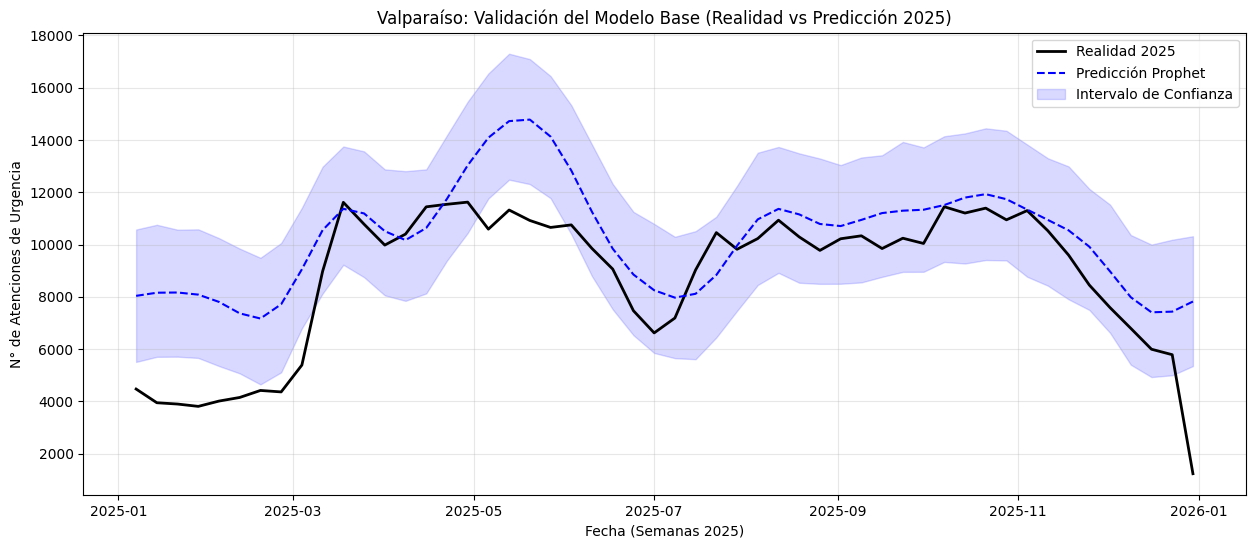

In [ ]:
test_plot = test.copy()
test_plot['ds'] = pd.to_datetime(test_plot['ds']).dt.tz_localize(None)

forecast_base_plot = forecast_base.copy()
forecast_base_plot['ds'] = pd.to_datetime(forecast_base_plot['ds']).dt.tz_localize(None)

# 2. Graficamos usando explícitamente los datos limpios
plt.figure(figsize=(15, 6))

# Realidad
plt.plot(test_plot['ds'], test_plot['y'], label='Realidad 2025', color='black', linewidth=2)

# Predicción
plt.plot(forecast_base_plot['ds'], forecast_base_plot['yhat'], label='Predicción Prophet', color='blue', linestyle='--')

# Sombreado de incertidumbre
plt.fill_between(forecast_base_plot['ds'],
                 forecast_base_plot['yhat_lower'],
                 forecast_base_plot['yhat_upper'],
                 color='blue', alpha=0.15, label='Intervalo de Confianza')

plt.title('Valparaíso: Validación del Modelo Base (Realidad vs Predicción 2025)')
plt.xlabel('Fecha (Semanas 2025)')
plt.ylabel('N° de Atenciones de Urgencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
y_pred_ex = forecast_base['yhat'].values

mae_base = mean_absolute_error(y_true, y_pred_ex)
mape_base = np.mean(np.abs((y_true-y_pred_ex) / y_true)) * 100
rmse_base = np.sqrt(mean_squared_error(y_true, y_pred_ex))
mejora_mae = ((mae_base - mae) / mae_base) * 100
mejora_mape = ((mape_base - mape) / mape_base) * 100
mejora_rmse = ((rmse_base - rmse) / rmse_base) * 100


print(f"--- Métricas para Valparaíso Modelo Base exógenas ---")
print(f"MAE Base: {mae_base:.2f} atenciones")
print(f"RMSE: {rmse_base:.2f}")
print(f"MAPE: {mape_base:.2f}%")
print(f"Mejora: {mejora_mae:.2f}%")
print(f"Mejora: {mejora_mape:.2f}%")
print(f"Mejora: {mejora_rmse:.2f}%")

--- Métricas para Valparaíso Modelo Base exógenas ---
MAE Base: 1698.90 atenciones
RMSE: 2233.24
MAPE: 35.38%
Mejora: 12.67%
Mejora: 12.94%
Mejora: 10.48%


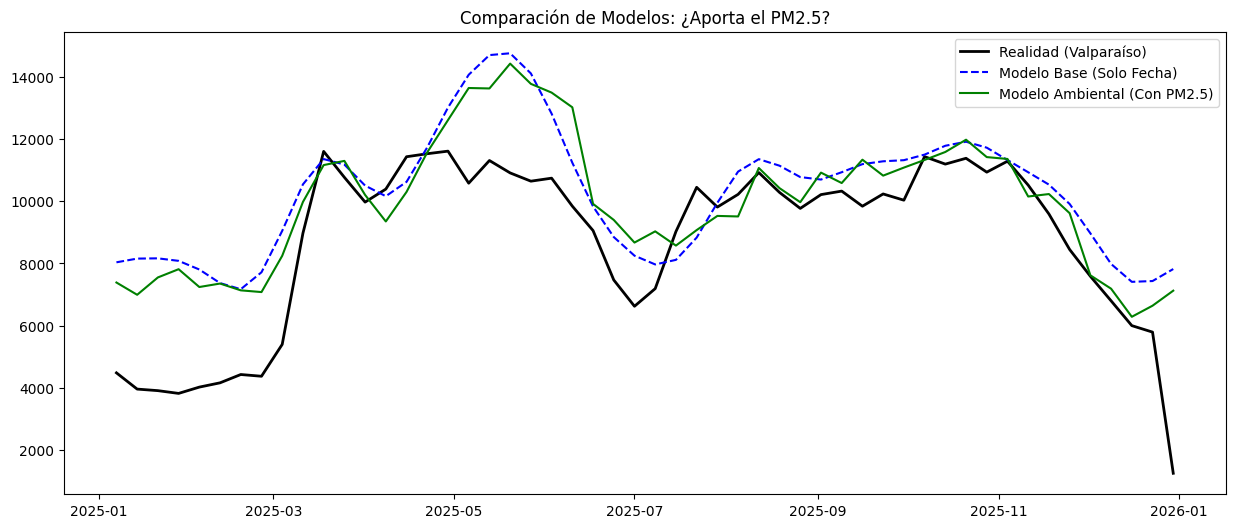

In [ ]:
plt.figure(figsize=(15, 6))
plt.plot(test_plot['ds'], test_plot['y'], label='Realidad (Valparaíso)', color='black', linewidth=2)
plt.plot(test_plot['ds'], forecast_base_plot['yhat'], label='Modelo Base (Solo Fecha)', linestyle='--', color='blue')
plt.plot(test_plot['ds'], forecast_plot['yhat'], label='Modelo Ambiental (Con PM2.5)', color='green')
plt.title('Comparación de Modelos: ¿Aporta el PM2.5?')
plt.legend()
plt.show()

In [ ]:
#Ahora realizaremos una comparación de los modelos anteriores, pero ademas considerando eventos especiales incio de clases, inicio vacaciones de invierno y fiestas patrias

# Definimos los eventos especiales
festivos_chile = pd.DataFrame({
  'holiday': 'evento_especial',
  'ds': pd.to_datetime([
    # Ingreso a Clases (aproximados por año)
    '2021-03-01', '2022-03-02', '2023-03-01', '2024-03-05', '2025-03-03',
    # Inicio Vacaciones Invierno (Semanas clave)
    '2021-07-12', '2022-06-30', '2023-07-03', '2024-06-24', '2025-07-07',
    # Fiestas Patrias
    '2021-09-17', '2022-09-16', '2023-09-16', '2024-09-16', '2025-09-18'
  ]),
  'lower_window': -1, # Días antes que afecta
  'upper_window': 7,  # Días despúes que afecta
})

# Al inicializar el modelo, le pasas este DataFrame
m_eventos = Prophet(
    yearly_seasonality=True,
    holidays=festivos_chile, weekly_seasonality=False, daily_seasonality=False
)

# Añadimos nuestras variables clave como "regresores"
m_eventos.add_regressor('pm25_lag')
m_eventos.add_regressor('temp')

m_eventos.fit(train)
forecast_eventos = m_eventos.predict(test)

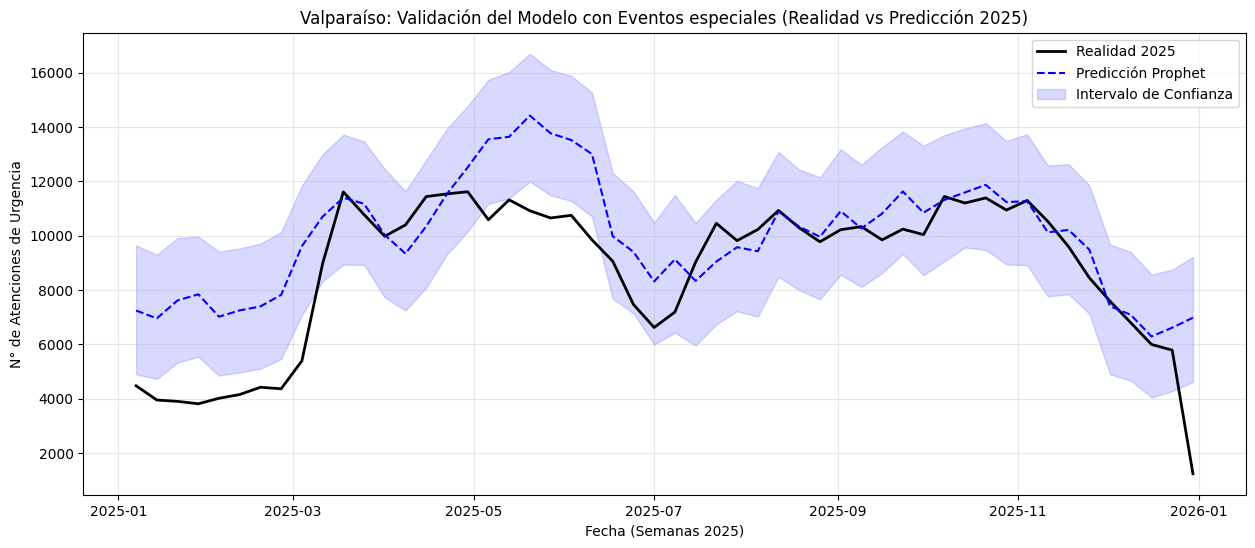

In [ ]:

forecast_eventos_plot = forecast_eventos.copy()
forecast_eventos_plot['ds'] = pd.to_datetime(forecast_eventos_plot['ds']).dt.tz_localize(None)

# 2. Graficamos usando explícitamente los datos limpios
plt.figure(figsize=(15, 6))

# Realidad
plt.plot(test_plot['ds'], test_plot['y'], label='Realidad 2025', color='black', linewidth=2)

# Predicción
plt.plot(forecast_eventos_plot['ds'], forecast_eventos_plot['yhat'], label='Predicción Prophet', color='blue', linestyle='--')

# Sombreado de incertidumbre
plt.fill_between(forecast_eventos_plot['ds'],
                 forecast_eventos_plot['yhat_lower'],
                 forecast_eventos_plot['yhat_upper'],
                 color='blue', alpha=0.15, label='Intervalo de Confianza')

plt.title('Valparaíso: Validación del Modelo con Eventos especiales (Realidad vs Predicción 2025)')
plt.xlabel('Fecha (Semanas 2025)')
plt.ylabel('N° de Atenciones de Urgencia')
plt.legend()
plt.grid(True, alpha=0.3)
plt.show()

In [ ]:
y_pred_ev = forecast_eventos['yhat'].values

mae_even = mean_absolute_error(y_true, y_pred_ev)
mape_even = np.mean(np.abs((y_true-y_pred_ev) / y_true)) * 100
rmse_even = np.sqrt(mean_squared_error(y_true, y_pred_ev))
mejora_mae2 = ((mae_even - mae) / mae_even) * 100
mejora_mape2 = ((mape_even - mape) / mape_even) * 100
mejora_rmse2 = ((rmse_even - rmse) / rmse_even) * 100


print(f"--- Métricas para Valparaíso Modelo Base exógenas ---")
print(f"MAE Eventos: {mae_even:.2f} atenciones")
print(f"RMSE Eventos: {rmse_even:.2f}")
print(f"MAPE Eventos: {mape_even:.2f}%")
print(f"Mejora: {mejora_mae2:.2f}%")
print(f"Mejora: {mejora_mape2:.2f}%")
print(f"Mejora: {mejora_rmse2:.2f}%")

--- Métricas para Valparaíso Modelo Base exógenas ---
MAE Eventos: 1501.57 atenciones
RMSE Eventos: 2050.13
MAPE Eventos: 31.16%
Mejora: 1.19%
Mejora: 1.14%
Mejora: 2.48%


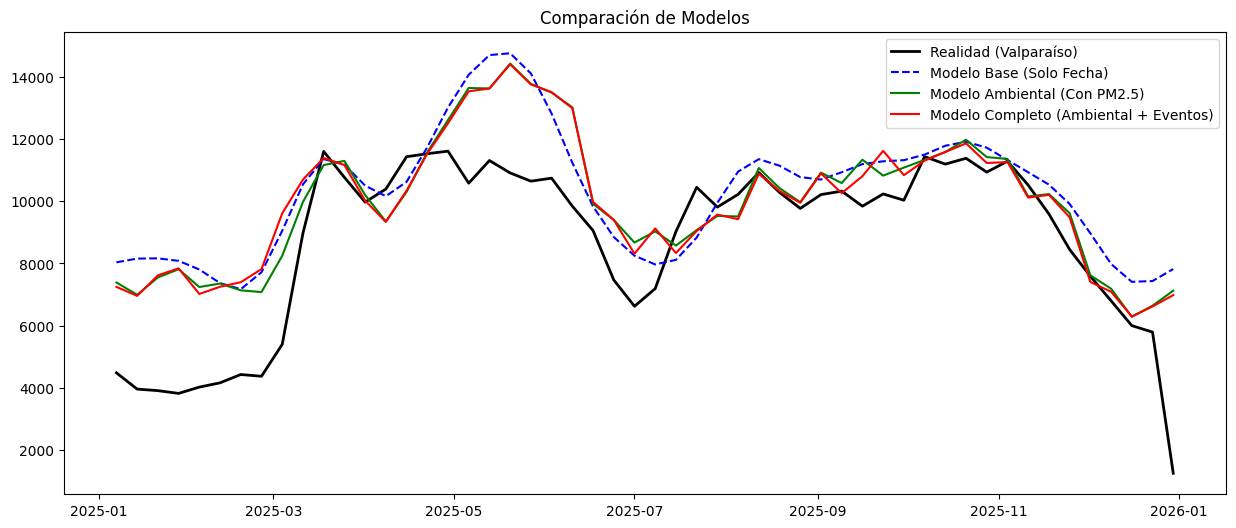

In [ ]:
#comparación visual de todos los modelos

plt.figure(figsize=(15, 6))
plt.plot(test_plot['ds'], test_plot['y'], label='Realidad (Valparaíso)', color='black', linewidth=2)
plt.plot(test_plot['ds'], forecast_base_plot['yhat'], label='Modelo Base (Solo Fecha)', linestyle='--', color='blue')
plt.plot(test_plot['ds'], forecast_plot['yhat'], label='Modelo Ambiental (Con PM2.5)', color='green')
plt.plot(test_plot['ds'], forecast_eventos_plot['yhat'], label='Modelo Completo (Ambiental + Eventos)', color='red')
plt.title('Comparación de Modelos')
plt.legend()
plt.show()

AHORA APLICAREMOS A TODAS LAS REGIONES PROPHET PARA VER SUS RESULTADOS

In [ ]:

# DEFUNIMOS LOS EVENTOS ESPECIALES
eventos = pd.DataFrame({
  'holiday': 'escolar_feriado',
  'ds': pd.to_datetime([# Ingreso a Clases (aproximados por año)
    '2021-03-01', '2022-03-02', '2023-03-01', '2024-03-05', '2025-03-03',
    # Inicio Vacaciones Invierno (Semanas clave)
    '2021-07-12', '2022-06-30', '2023-07-03', '2024-06-24', '2025-07-07',
    # Fiestas Patrias
    '2021-09-17', '2022-09-16', '2023-09-16', '2024-09-16', '2025-09-18']),
  'lower_window': -1, 'upper_window': 7
})

resultados_prophet_comp = []
regiones = df['RegionNombre'].unique()

for reg in regiones:
    try:
        df_reg = df[df['RegionNombre'] == reg].copy()
        df_p = df_reg[['Semana', 'Atenciones_Urg', 'PM25_Lag1', 'Temp_Mediana_Semanal']].copy()
        df_p.columns = ['ds', 'y', 'pm25_lag', 'temp']
        df_p['ds'] = pd.to_datetime(df_p['ds']).dt.tz_localize(None)

        train = df_p[df_p['ds'] < '2025-01-01']
        test = df_p[df_p['ds'] >= '2025-01-01']

        if len(test) < 5: continue

        # --- NIVEL 1: Modelo Base (Solo Fecha) ---
        m_base = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False)
        m_base.fit(train[['ds', 'y']])
        f_base = m_base.predict(test[['ds']])

        y_true = test['y'].values
        y_pred_base = f_base['yhat'].values

        mae_base = mean_absolute_error(y_true, y_pred_base)
        mape_base = np.mean(np.abs((y_true - y_pred_base) / (y_true))) * 100
        rmse_base = np.sqrt(mean_squared_error(y_true, y_pred_base))

        # --- NIVEL 2: Modelo Final (Ambiental + Eventos) ---
        m_final = Prophet(yearly_seasonality=True, weekly_seasonality=False, daily_seasonality=False, holidays=eventos)
        m_final.add_regressor('pm25_lag')
        m_final.add_regressor('temp')
        m_final.fit(train)
        f_final = m_final.predict(test)

        y_pred_final = f_final['yhat'].values

        mae_final = mean_absolute_error(y_true, y_pred_final)
        rmse_final = np.sqrt(mean_squared_error(y_true, y_pred_final))
        mape_final = np.mean(np.abs((y_true - y_pred_final) / (y_true))) * 100

        mejora_mae = ((mae_base - mae_final) / mae_base) * 100

        resultados_prophet_comp.append({
            'Región': reg,
            'MAE Base': round(mae_base, 1),
            'MAE Final': round(mae_final, 1),
            'RMSE Base': round(rmse_base, 1),
            'RMSE Final': round(rmse_final, 1),
            'MAPE Base %': round(mape_base, 2),
            'MAPE Final %': round(mape_final, 2),
            'Mejora MAE %': round(mejora_mae, 2)
        })
        print(f"Procesado: {reg}")

    except Exception as e:
        print(f"Error en {reg}: {e}")

df_ranking = pd.DataFrame(resultados_prophet_comp).sort_values('Mejora MAE %', ascending=False)
print("\n--- RESULTADOS FINALES PROPHET ---")
print(df_ranking.to_string(index=False))

Procesado: RM
Procesado: Aysén
Procesado: Araucanía
Procesado: Los Lagos
Procesado: Los Ríos
Procesado: Valparaíso
Procesado: Ñuble
Procesado: Bío-Bío
Procesado: O'Higgins
Procesado: Maule

--- RESULTADOS FINALES PROPHET ---
    Región  MAE Base  MAE Final  RMSE Base  RMSE Final  MAPE Base %  MAPE Final %  Mejora MAE %
Valparaíso    1698.9     1501.6     2233.2      2050.1        35.38         31.16         11.62
   Bío-Bío    3121.7     2794.8     3725.5      3487.4        50.46         46.63         10.47
 O'Higgins    1231.2     1189.9     1544.6      1461.1        45.47         42.49          3.35
        RM    5501.0     5424.4     7518.0      6976.6        38.64         34.28          1.39
  Los Ríos     573.8      569.1      707.7       713.3        34.48         33.68          0.81
 Araucanía    1367.0     1408.2     1639.1      1724.0        43.21         42.36         -3.01
 Los Lagos    1204.1     1242.4     1469.0      1517.7        36.48         37.90         -3.18
     Ay

In [ ]:
print("Total observaciones:", len(df_prophet))
print("Entrenamiento:", len(train))
print("Prueba:", len(test))

Total observaciones: 262
Entrenamiento: 210
Prueba: 52
